In [18]:
!pip install snowflake-connector-python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import snowflake.connector

In [19]:
conn = snowflake.connector.connect(
    user = 'Jeevanraj',
    password = 'xxx',
    account = 'BLHUVTW-IK53044',
    database = 'TITANIC_RANDOM',
    schema = 'PUBLIC',
    warehouse = 'COMPUTE_WH'
)

In [20]:
query = 'select * from titanic'
df = pd.read_sql(query,conn)
conn.close()

/tmp/ipykernel_19574/1278704479.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


In [21]:
df.head()

,PASSENGERID,SURVIVED,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,CABIN,EMBARKED
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,None,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,None,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,None,S


In [22]:
df.tail()

,PASSENGERID,SURVIVED,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,CABIN,EMBARKED
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,None,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,None,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,None,Q


In [23]:
df.isnull().sum()

,0
PASSENGERID,0
SURVIVED,0
PCLASS,0
NAME,0
SEX,0
AGE,177
SIBSP,0
PARCH,0
TICKET,0
FARE,0


In [24]:
df = df.drop(['CABIN'],axis=1)

In [25]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy = 'mean')
imp1 = SimpleImputer(strategy = 'most_frequent')
df[['AGE']] = imp.fit_transform(df[['AGE']])
df['EMBARKED'].fillna(df['EMBARKED'].mode()[0],inplace=True)
df.isna().sum()

/tmp/ipykernel_19574/1753921755.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['EMBARKED'].fillna(df['EMBARKED'].mode()[0],inplace=True)


,0
PASSENGERID,0
SURVIVED,0
PCLASS,0
NAME,0
SEX,0
AGE,0
SIBSP,0
PARCH,0
TICKET,0
FARE,0


In [26]:
df.replace('None',)

/tmp/ipykernel_19574/747514743.py:1: FutureWarning: DataFrame.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  df.replace('None',)


,PASSENGERID,SURVIVED,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,EMBARKED
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


In [27]:
df

,PASSENGERID,SURVIVED,PCLASS,NAME,SEX,AGE,SIBSP,PARCH,TICKET,FARE,EMBARKED
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


In [28]:
df.isnull().sum()

,0
PASSENGERID,0
SURVIVED,0
PCLASS,0
NAME,0
SEX,0
AGE,0
SIBSP,0
PARCH,0
TICKET,0
FARE,0


<Axes: >

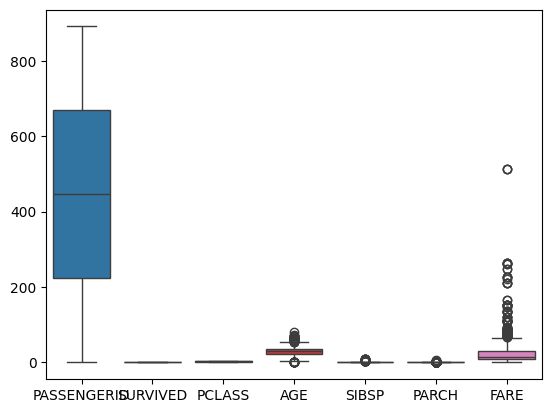

In [29]:
import seaborn as sns
sns.boxplot(df)

In [35]:
X = df[
  ['PASSENGERID',
   'PCLASS',
   'SEX',
   'AGE',
   'SIBSP',
   'PARCH',
   'FARE',
   'EMBARKED'
   ]
]
y = df["SURVIVED"]

In [31]:
x = df.drop('SURVIVED', axis =1)
y = df['SURVIVED']

In [32]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_cols = X.select_dtypes(include='object').columns

ct = ColumnTransformer([('onehot', OneHotEncoder(handle_unknown='ignore'),cat_cols)],remainder='passthrough')
X_encoded = ct.fit_transform(X)

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8156424581005587
